In [42]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, display
import utils as ut

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Introduction

The purpose of this notebook is to ensure that my implementation of the XY model is aligned with existing literature, and hence validate that I have implemented everything correctly.

Main reference is the Wikipedia page on XY model: https://en.wikipedia.org/wiki/Classical_XY_model

## Mean-square magnetisation

The Wikipedia page provides a plot of mean-squared magnetisation per spin with respect to $k_B T/ J$ for a $25\times 25$ lattice:

<p align="center">
  <img src="images/mean_sq_mag.png" alt="derivation of magnetic susceptibility" width="600" align="center"/>
</p>

My code will attempt to recreate this curve.

# Experiment

In [43]:
L = 20 # number of spins in one side of the square lattice (so total there are N = L^2 spins)

# hamiltonian parameters
H = 0 # H = mu_s * B / J
phi = 0


# metropolis parameters
delta = np.pi / 4 # the maximum a spin can rotate in one iteration
num_sweeps = 15000 # number of monte carlo sweeps = num_sweeps * N monte carlo iterations
save_every = L**2 # save snapshots of the lattice for animation every <save_every> monte carlo iteration

# initial portion of run to discard so only equilibrium states are considered for stats calculations
burn_in_fraction = 0.5 

In [44]:
L = 25
N = L**2

T_values = np.arange(0.4, 1.61, 0.05)
BJ_values = 1 / T_values

n_runs = 10
all_runs = []

for _ in range(n_runs):
    mean_square_magnetisations = []

    for BJ in BJ_values:
        lattice = ut.generate_lattice(L)
        energy = ut.get_energy(lattice, H, phi)

        steps = N * num_sweeps
        burn_in_steps = int(burn_in_fraction * steps)
        measure_steps = steps - burn_in_steps

        mid_lattice, _, _, energies, _ = ut.metropolis(
            lattice, burn_in_steps, BJ, H, phi, energy, delta
        )

        _, total_spins_x, total_spins_y, _, _ = ut.metropolis(
            mid_lattice, measure_steps, BJ, H, phi, energies[-1], delta
        )

        mean_square_magnetisation = np.mean(
            total_spins_x**2 + total_spins_y**2
        ) / N**2

        mean_square_magnetisations.append(mean_square_magnetisation)

    all_runs.append(mean_square_magnetisations)

mean_m2 = np.mean(all_runs, axis=0)

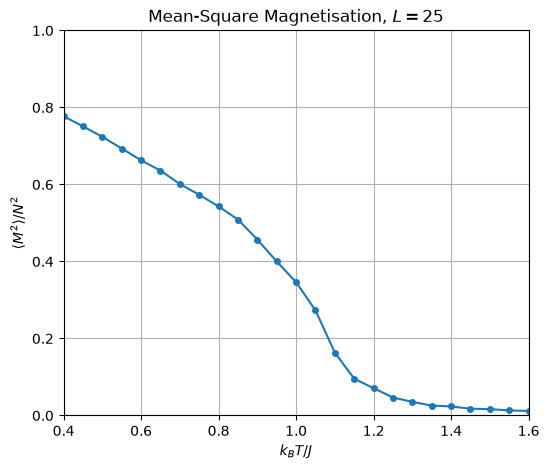

In [45]:
plt.figure(figsize=(6, 5))

plt.plot(
    T_values,
    mean_m2,
    marker='o',
    markersize=4
)

plt.xlabel(r'$k_B T/J$')
plt.ylabel(r'$\langle M^2\rangle/N^2$')
plt.title(r'Mean-Square Magnetisation, $L=25$')

plt.xlim(0.4, 1.6)
plt.ylim(0, 1)

plt.grid()
plt.show()

# Comparison with literature

Superimposing the two curves, we see that there is an almost exact match, hence validating my implementation.

<p align="center">
  <img src="images/mean_sq_mag_combined.png" alt="derivation of magnetic susceptibility" width="600" align="center"/>
</p>